I0000 00:00:1779440488.356769   10757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779440488.357717   10757 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779440488.434858   10757 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779440489.676150   10757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Rebuilding empty U-Net architecture shell...


E0000 00:00:1779440490.343792   10757 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779440490.359729   10757 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model is loaded with inference_v1 weights


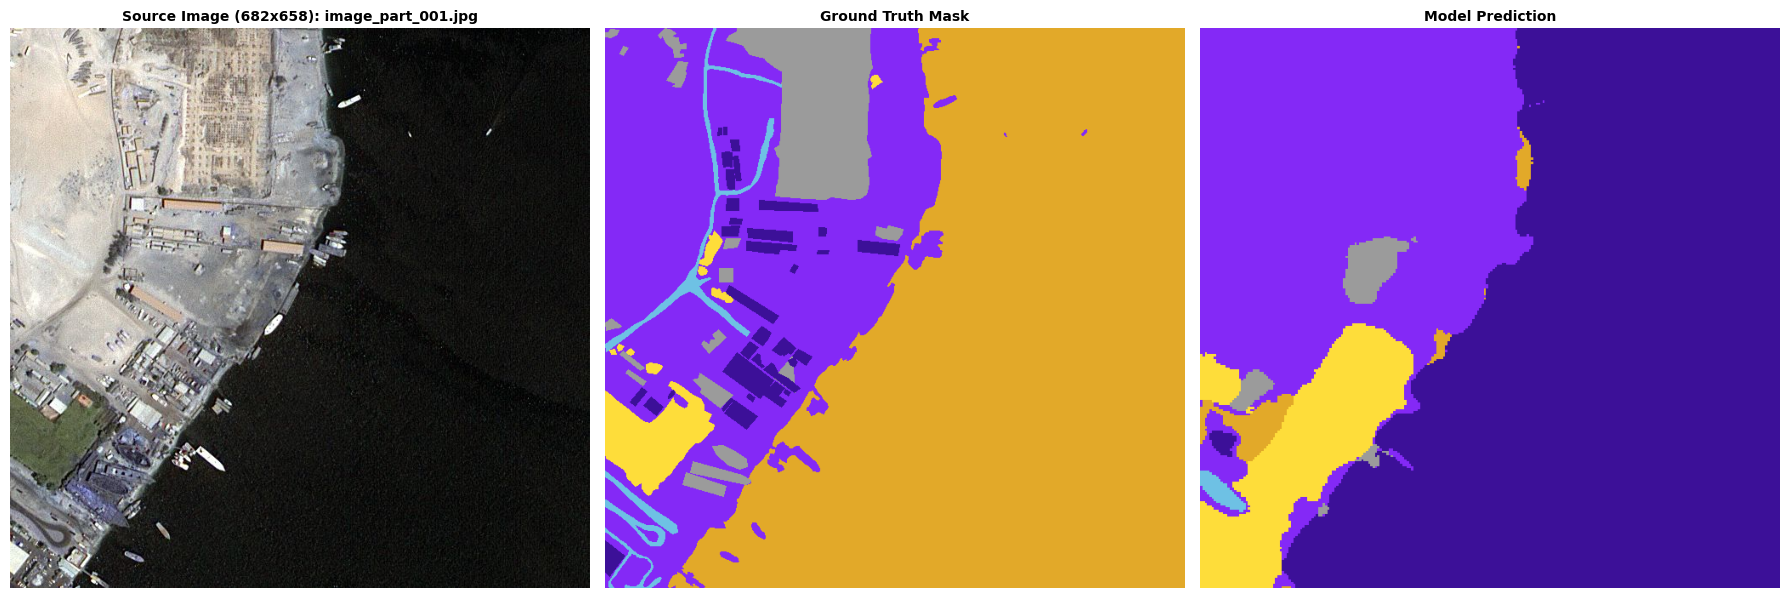

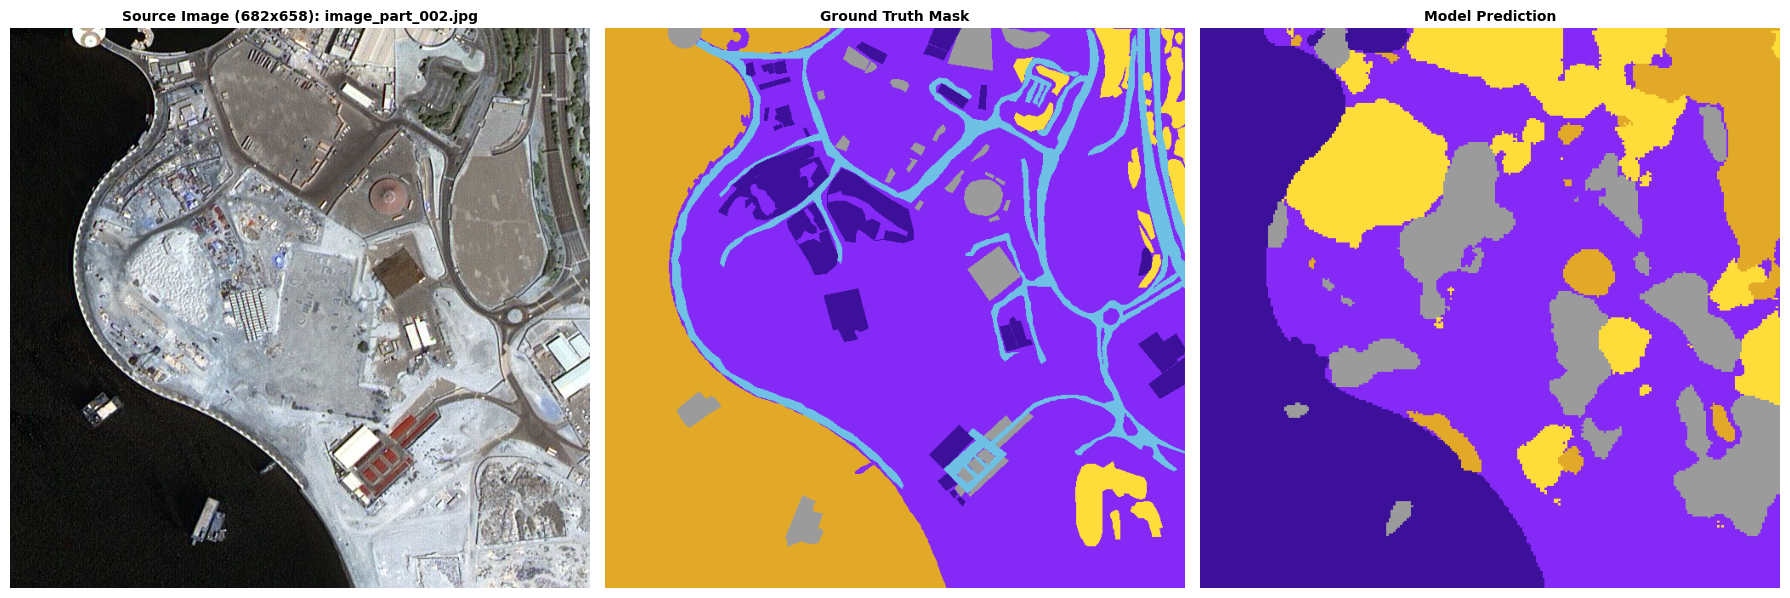

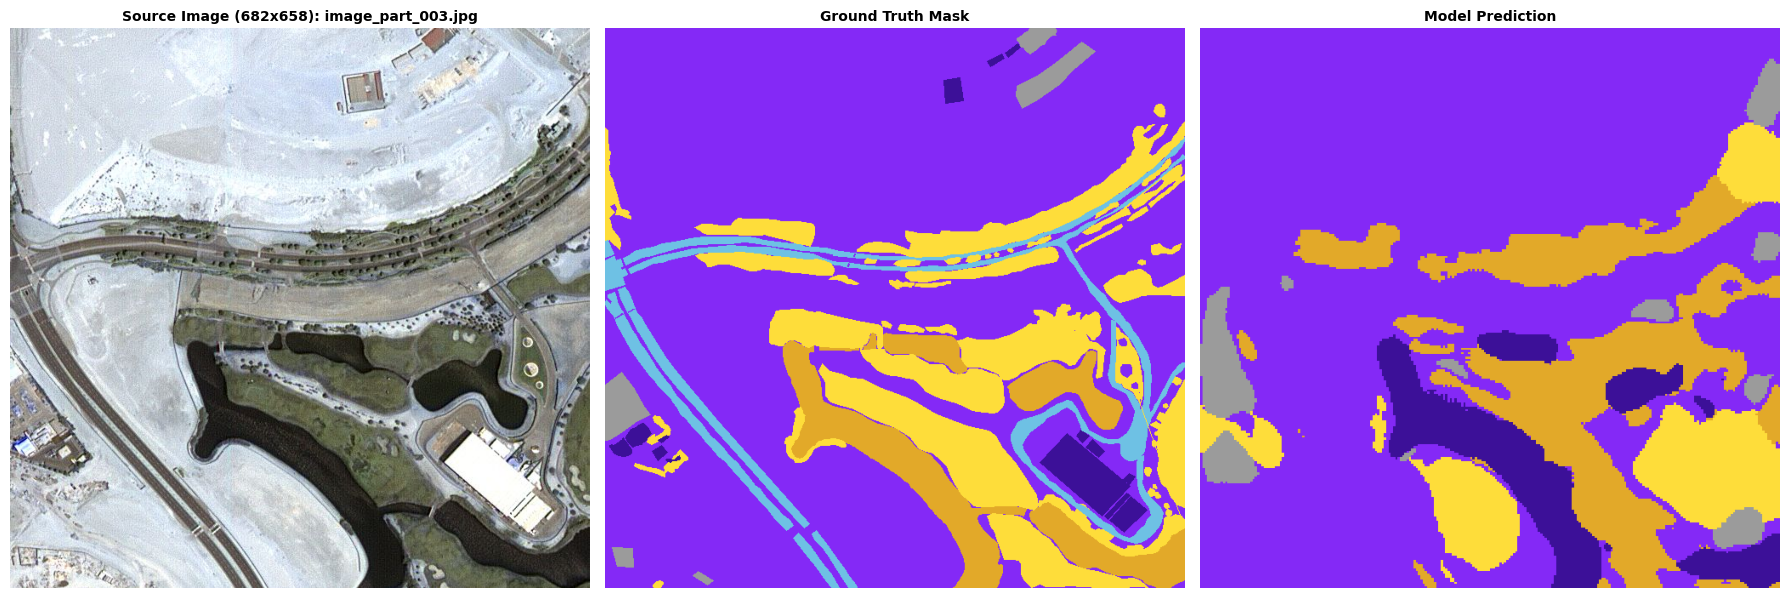

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

WEIGHTS_PATH = "model_v1.keras"
IMAGES_DIR = "/home/ayzrixsiev/Downloads/DubaiDataset/Semantic segmentation dataset/Tile 3/images"
MASKS_DIR = "/home/ayzrixsiev/Downloads/DubaiDataset/Semantic segmentation dataset/Tile 3/masks"

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_CHANNELS = 3
TOTAL_CLASSES = 6

COLOR_MAP = {
    0: [60, 16, 152],    # Building
    1: [132, 41, 246],   # Land/Dirt
    2: [110, 193, 228],  # Road
    3: [254, 221, 58],   # Vegetation
    4: [226, 169, 41],   # Water
    5: [155, 155, 155]   # Unlabeled/Background
}

def map_classes_to_rgb(mask_canvas):
    height, width = mask_canvas.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)
    for class_idx, color in COLOR_MAP.items():
        rgb_image[mask_canvas == class_idx] = color
    return rgb_image

def rgb_to_class_indices(rgb_mask):
    height, width, _ = rgb_mask.shape
    class_mask = np.zeros((height, width), dtype=np.uint8)
    
    for class_idx, color in COLOR_MAP.items():
        matches = np.all(rgb_mask == color, axis=-1)
        class_mask[matches] = class_idx
    return class_mask

def multi_class_unet_model(n_classes=6, image_height=256, image_width=256, image_channels=3):
    inputs = tf.keras.layers.Input((image_height, image_width, image_channels))
    
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    
    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    
    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    
    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    
    outputs = tf.keras.layers.Conv2D(n_classes, (1, 1), activation='softmax')(c9)
    
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

tf.keras.backend.clear_session()
print("Rebuilding empty U-Net architecture shell...")
model = multi_class_unet_model(
    n_classes=TOTAL_CLASSES, 
    image_height=IMAGE_HEIGHT, 
    image_width=IMAGE_WIDTH, 
    image_channels=IMAGE_CHANNELS
)

model.load_weights(WEIGHTS_PATH)
print("Model is loaded with inference_v1 weights")

sample_image_files = sorted(os.listdir(IMAGES_DIR))[:3]

for file_name in sample_image_files:
    img_path = os.path.join(IMAGES_DIR, file_name)
    mask_path = os.path.join(MASKS_DIR, file_name.replace(".jpg", ".png"))
    
    if not os.path.exists(mask_path):
        continue
        
    raw_img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w, _ = raw_img.shape
    
    resized_img = cv2.resize(raw_img, (IMAGE_HEIGHT, IMAGE_WIDTH))
    normalized_input = np.expand_dims(resized_img / 255.0, axis=0)
    
    raw_mask_rgb = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    raw_mask_rgb = cv2.cvtColor(raw_mask_rgb, cv2.COLOR_BGR2RGB)
    true_class_map = rgb_to_class_indices(raw_mask_rgb)
    true_mask_scaled = cv2.resize(true_class_map, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    true_mask_rgb = map_classes_to_rgb(true_mask_scaled)
    
    raw_prediction = model.predict(normalized_input, verbose=0)
    predicted_classes = np.argmax(raw_prediction[0], axis=-1).astype(np.uint8)
    
    predicted_classes_scaled = cv2.resize(
        predicted_classes, 
        (orig_w, orig_h), 
        interpolation=cv2.INTER_NEAREST
    )
    predicted_mask_rgb = map_classes_to_rgb(predicted_classes_scaled)
    
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(raw_img)
    plt.title(f"Source Image ({orig_w}x{orig_h}): {file_name}", fontsize=10, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_rgb)
    plt.title("Ground Truth Mask", fontsize=10, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask_rgb)
    plt.title("Model Prediction", fontsize=10, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()